# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 17: AUDIO CNN ON 10-GENRE PILOT
# ============================================================
# Purpose:
# This notebook trains the improved audio CNN on the broader
# 10-genre pilot derived from FMA-Large.
#
# The goal is to:
# 1. Load the 10-genre pilot metadata
# 2. Extract Mel spectrograms from audio files
# 3. Train the improved CNN architecture
# 4. Evaluate validation and test performance
# 5. Save model outputs for later hybrid fusion
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, callbacks, regularizers

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except:
    pass

print("Seeds set to:", SEED)

Seeds set to: 42


In [2]:
# ============================================================
# 2. LOAD 10-GENRE PILOT METADATA
# ============================================================

pilot_df = pd.read_csv("../data/processed/audio_large_pilot_metadata_10genre.csv")

print("10-genre pilot metadata shape:", pilot_df.shape)
display(pilot_df.head())

print("\nClass distribution:")
print(pilot_df["genre_top"].value_counts())

print("\nSplit distribution:")
print(pilot_df["split"].value_counts())

10-genre pilot metadata shape: (6329, 5)


,track_id,genre_top,split,audio_path,audio_exists
0,183,Rock,test,../data/raw/audio/fma_large\000\000183.mp3,True
1,184,Rock,test,../data/raw/audio/fma_large\000\000184.mp3,True
2,191,Folk,training,../data/raw/audio/fma_large\000\000191.mp3,True
3,205,Folk,training,../data/raw/audio/fma_large\000\000205.mp3,True
4,306,Rock,training,../data/raw/audio/fma_large\000\000306.mp3,True



Class distribution:
genre_top
Experimental     1781
Rock             1546
Electronic        626
Pop               456
Folk              404
Hip-Hop           382
Instrumental      375
Spoken            301
International     241
Classical         217
Name: count, dtype: int64

Split distribution:
split
test          2360
validation    2169
training      1800
Name: count, dtype: int64


In [3]:
# ============================================================
# 3. DEFINE MEL SPECTROGRAM FUNCTION
# ============================================================

def extract_mel_spectrogram(file_path, sr=22050, duration=30, n_mels=128, target_width=1292):
    try:
        audio, sample_rate = librosa.load(file_path, sr=sr, duration=duration)

        mel_spec = librosa.feature.melspectrogram(
            y=audio,
            sr=sample_rate,
            n_mels=n_mels
        )

        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        if mel_spec_db.shape[1] < target_width:
            pad_width = target_width - mel_spec_db.shape[1]
            mel_spec_db = np.pad(
                mel_spec_db,
                ((0, 0), (0, pad_width)),
                mode="constant"
            )
        else:
            mel_spec_db = mel_spec_db[:, :target_width]

        return mel_spec_db

    except Exception as e:
        print("Error processing:", file_path, e)
        return None

In [4]:
# ============================================================
# 4. REMOVE BAD / UNREADABLE AUDIO FILES
# ============================================================

def can_load_audio(file_path, sr=22050, duration=3):
    try:
        audio, _ = librosa.load(file_path, sr=sr, duration=duration)
        return audio is not None and len(audio) > 0
    except:
        return False

pilot_df["can_load"] = pilot_df["audio_path"].apply(can_load_audio)

print("Readable audio files:")
print(pilot_df["can_load"].value_counts())

pilot_df = pilot_df[pilot_df["can_load"] == True].copy().reset_index(drop=True)

print("Clean 10-genre pilot shape after removing bad files:", pilot_df.shape)

print("\nClass distribution after cleanup:")
print(pilot_df["genre_top"].value_counts())

print("\nSplit distribution after cleanup:")
print(pilot_df["split"].value_counts())

C:\Users\jdevo\AppData\Local\Temp\ipykernel_40160\1324943585.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(file_path, sr=sr, duration=duration)
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Readable audio files:
can_load
True     6312
False      17
Name: count, dtype: int64
Clean 10-genre pilot shape after removing bad files: (6312, 6)

Class distribution after cleanup:
genre_top
Experimental     1779
Rock             1545
Electronic        626
Pop               456
Folk              404
Hip-Hop           382
Instrumental      374
Spoken            299
International     230
Classical         217
Name: count, dtype: int64

Split distribution after cleanup:
split
test          2356
validation    2167
training      1789
Name: count, dtype: int64


In [5]:
# ============================================================
# 5. ENCODE LABELS AND CREATE SPLIT DATAFRAMES
# ============================================================

label_encoder = LabelEncoder()
label_encoder.fit(pilot_df["genre_top"])

pilot_df["label"] = label_encoder.transform(pilot_df["genre_top"])

train_df = pilot_df[pilot_df["split"] == "training"].copy().reset_index(drop=True)
val_df = pilot_df[pilot_df["split"] == "validation"].copy().reset_index(drop=True)
test_df = pilot_df[pilot_df["split"] == "test"].copy().reset_index(drop=True)

print("Encoded classes:")
print(label_encoder.classes_)

print("\nTrain shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Encoded classes:
['Classical' 'Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'International' 'Pop' 'Rock' 'Spoken']

Train shape: (1789, 7)
Validation shape: (2167, 7)
Test shape: (2356, 7)


In [6]:
# ============================================================
# 6. CREATE BATCH GENERATOR
# ============================================================

from tensorflow.keras.utils import Sequence

class AudioDataGenerator(Sequence):
    def __init__(self, df, batch_size=8, shuffle=False, **kwargs):
        super().__init__(**kwargs)
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_df = self.df.iloc[batch_indexes]

        X_batch = []
        y_batch = []

        for _, row in batch_df.iterrows():
            spec = extract_mel_spectrogram(row["audio_path"])

            if spec is not None:
                spec = spec[..., np.newaxis]

                denom = np.max(np.abs(spec))
                if denom != 0:
                    spec = spec / denom

                X_batch.append(spec.astype(np.float32))
                y_batch.append(int(row["label"]))

        return np.array(X_batch, dtype=np.float32), np.array(y_batch, dtype=np.int32)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

In [7]:
# ============================================================
# 7. CREATE TRAIN / VALIDATION / TEST GENERATORS
# ============================================================

# Start with batch size 8 to reduce memory pressure.
# If training still crashes, change this to 4.

BATCH_SIZE = 8

train_gen = AudioDataGenerator(train_df, batch_size=BATCH_SIZE, shuffle=True)
val_gen = AudioDataGenerator(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_gen = AudioDataGenerator(test_df, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_gen))
print("Validation batches:", len(val_gen))
print("Test batches:", len(test_gen))

# Peek at one batch to confirm shape
X_sample, y_sample = train_gen[0]
print("Sample batch X shape:", X_sample.shape)
print("Sample batch y shape:", y_sample.shape)

Train batches: 224
Validation batches: 271
Test batches: 295
Sample batch X shape: (8, 128, 1292, 1)
Sample batch y shape: (8,)


In [8]:
# ============================================================
# 8A. COMPUTE CLASS WEIGHTS
# ============================================================

classes = np.unique(train_df["label"])

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_values)
}

print("Class Weights:")
print(class_weights)

Class Weights:
{0: 0.9938888888888889, 1: 0.9938888888888889, 2: 0.9938888888888889, 3: 0.9938888888888889, 4: 0.9938888888888889, 5: 0.9938888888888889, 6: 1.0461988304093568, 7: 0.9938888888888889, 8: 0.9938888888888889, 9: 1.0050561797752808}


In [9]:
# ============================================================
# 8B. CLEAR TENSORFLOW SESSION BEFORE BUILDING MODEL
# ============================================================

import gc
tf.keras.backend.clear_session()
gc.collect()

print("Cleared TensorFlow session.")


Cleared TensorFlow session.


In [10]:
# ============================================================
# 9. BUILD IMPROVED CNN
# ============================================================

input_shape = (128, 1292, 1)

improved_cnn = models.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),

    layers.Dense(len(label_encoder.classes_), activation="softmax")
])

improved_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

improved_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 1292, 32)  │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 1292, 32)  │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 646, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 646, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 646, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 323, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 323, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 323, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 161, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 161, 128)   │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 161, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,570 (978.79 KB)

 Trainable params: 249,866 (976.04 KB)

 Non-trainable params: 704 (2.75 KB)

In [11]:
# ============================================================
# 10. DEFINE CALLBACKS
# ============================================================

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [12]:
# ============================================================
# 11. TRAIN IMPROVED CNN
# ============================================================

history_improved = improved_cnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 559s 2s/step - accuracy: 0.2062 - loss: 2.3178 - val_accuracy: 0.4015 - val_loss: 1.9625 - learning_rate: 5.0000e-04
Epoch 2/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 617s 3s/step - accuracy: 0.3185 - loss: 2.1172 - val_accuracy: 0.3636 - val_loss: 1.9293 - learning_rate: 5.0000e-04
Epoch 3/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 617s 3s/step - accuracy: 0.3454 - loss: 1.9872 - val_accuracy: 0.3429 - val_loss: 2.1130 - learning_rate: 5.0000e-04
Epoch 4/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3683 - loss: 1.9168
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
224/224 ━━━━━━━━━━━━━━━━━━━━ 655s 3s/step - accuracy: 0.3683 - loss: 1.9169 - val_accuracy: 0.1818 - val_loss: 2.1656 - learning_rate: 5.0000e-04
Epoch 5/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 586s 3s/step - accuracy: 0.4240 - loss: 1.8484 - val_accuracy: 0.3447 - val_loss: 1.9652 - learning_rate: 2.5000e-04
Epoch 6/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.

In [13]:
# ============================================================
# 12. EVALUATE IMPROVED CNN
# ============================================================

improved_test_loss, improved_test_accuracy = improved_cnn.evaluate(test_gen)

print("10-Genre Improved CNN Test Accuracy:", improved_test_accuracy)

295/295 ━━━━━━━━━━━━━━━━━━━━ 296s 1s/step - accuracy: 0.3285 - loss: 1.9032
10-Genre Improved CNN Test Accuracy: 0.31409168243408203


In [14]:
# ============================================================
# 13. CLASSIFICATION REPORT
# ============================================================

y_test = test_df["label"].to_numpy()
y_pred_probs_improved = improved_cnn.predict(test_gen)
y_pred_improved = np.argmax(y_pred_probs_improved, axis=1)

print(classification_report(
    y_test,
    y_pred_improved,
    target_names=label_encoder.classes_,
    zero_division=0
))

295/295 ━━━━━━━━━━━━━━━━━━━━ 279s 947ms/step
               precision    recall  f1-score   support

    Classical       0.00      0.00      0.00        25
   Electronic       0.22      0.34      0.27       207
 Experimental       0.50      0.16      0.25       858
         Folk       0.00      0.00      0.00       147
      Hip-Hop       0.12      0.01      0.02       103
 Instrumental       0.00      0.00      0.00       134
International       0.00      0.00      0.00        25
          Pop       0.00      0.00      0.00        85
         Rock       0.49      0.67      0.57       753
       Spoken       0.03      1.00      0.06        19

     accuracy                           0.31      2356
    macro avg       0.14      0.22      0.12      2356
 weighted avg       0.36      0.31      0.30      2356



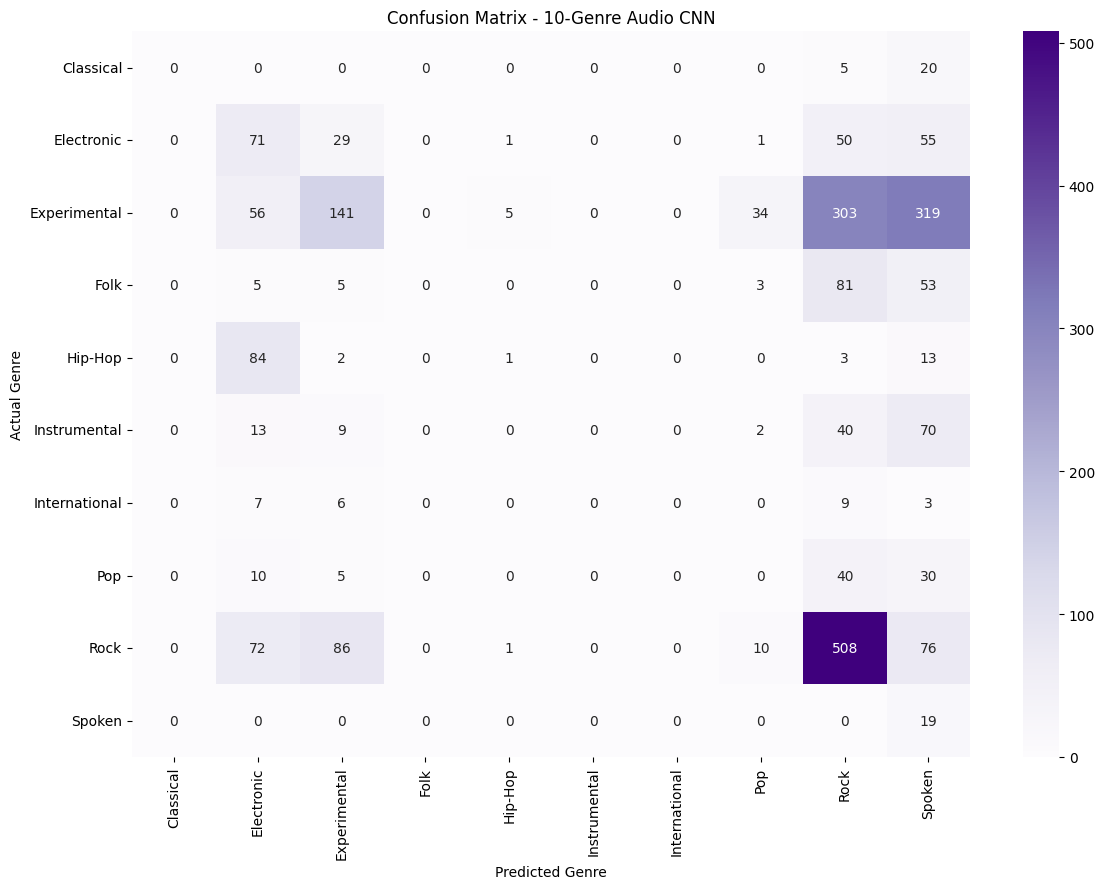

In [15]:
# ============================================================
# 14. CONFUSION MATRIX
# ============================================================

cm_improved = confusion_matrix(y_test, y_pred_improved)

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm_improved,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Confusion Matrix - 10-Genre Audio CNN")
plt.tight_layout()
plt.show()

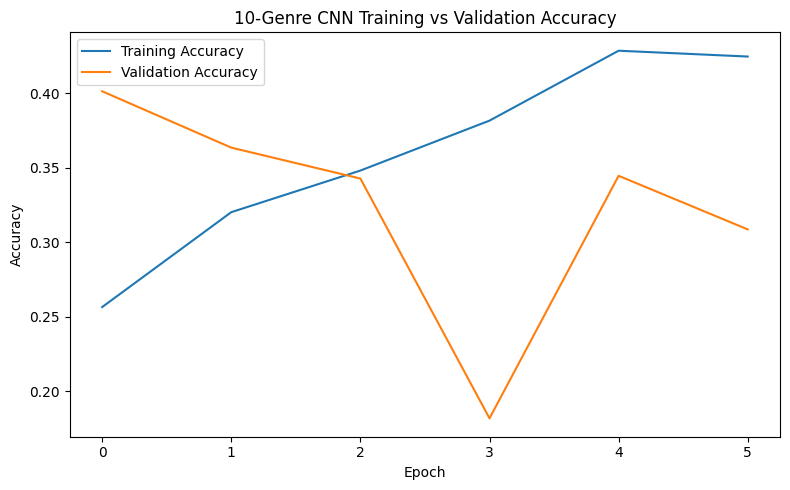

In [16]:
# ============================================================
# 15. TRAINING HISTORY
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_improved.history["accuracy"], label="Training Accuracy")
plt.plot(history_improved.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("10-Genre CNN Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# 16. SAVE MODEL AND OUTPUTS
# ============================================================

os.makedirs("../models", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

improved_cnn.save("../models/improved_audio_cnn_10genre.keras")

val_probs_cnn = improved_cnn.predict(val_gen)
test_probs_cnn = improved_cnn.predict(test_gen)

y_val = val_df["label"].to_numpy()
y_test = test_df["label"].to_numpy()

np.save("../data/processed/val_probs_cnn_10genre.npy", val_probs_cnn)
np.save("../data/processed/test_probs_cnn_10genre.npy", test_probs_cnn)

np.save("../data/processed/y_val_cnn_10genre.npy", y_val)
np.save("../data/processed/y_test_cnn_10genre.npy", y_test)
np.save("../data/processed/cnn_label_classes_10genre.npy", label_encoder.classes_)

with open("../data/processed/improved_cnn_test_accuracy_10genre.txt", "w") as f:
    f.write(str(improved_test_accuracy))

print("Saved 10-genre CNN model and outputs.")

271/271 ━━━━━━━━━━━━━━━━━━━━ 270s 997ms/step
295/295 ━━━━━━━━━━━━━━━━━━━━ 288s 978ms/step
Saved 10-genre CNN model and outputs.


In [18]:
# ============================================================
# 17. INTERPRETATION NOTES
# ============================================================

print("1. This notebook trains the improved audio CNN on the broader 10-genre pilot.")
print("2. A generator-based pipeline is used to avoid loading all spectrograms into RAM at once.")
print("3. Bad or unreadable audio files are removed before training.")
print("4. The saved outputs will be used for later 10-genre hybrid fusion.")

1. This notebook trains the improved audio CNN on the broader 10-genre pilot.
2. A generator-based pipeline is used to avoid loading all spectrograms into RAM at once.
3. Bad or unreadable audio files are removed before training.
4. The saved outputs will be used for later 10-genre hybrid fusion.
